In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split
import torch.nn as nn
import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(42)

In [3]:
df = pd.read_csv("/Users/anandsharma/Documents/PhD/LearnML/CampusX/Datasets/fashionmnist/versions/4/fashion-mnist_train.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: mps


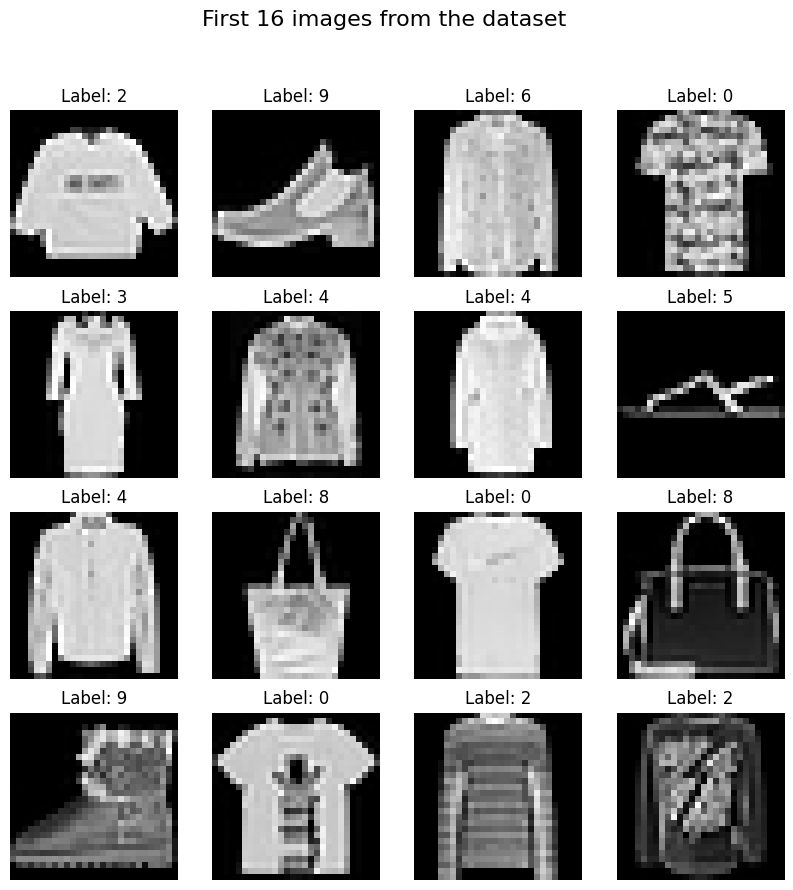

In [5]:
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 images from the dataset", fontsize=16)

for i, ax in enumerate(axes.flatten()):
    image = df.iloc[i, 1:].values.reshape(28, 28)
    label = df.iloc[i, 0]
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

In [6]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# Scaling the data
X_train = X_train / 255.0
X_test = X_test / 255.0

In [10]:
# Create CustomDataset class

class CustomDataset(Dataset):

    def __init__(self, features, labels): 
        self.features = torch.tensor(features, dtype=torch.float32).reshape(-1,1,28,28)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]


In [11]:
# Create train and test datasets objects
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

In [12]:
# Cretate train and test dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True) #, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False) #, pin_memory=True)

In [13]:
len(train_loader), len(test_loader)

(1500, 375)

In [19]:
class MyNN(nn.Module): 

    def __init__(self, input_features, num_features):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=input_features, out_channels=32, kernel_size=3, padding='same'),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding='same'),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)

        ) 

        self.classifier = nn.Sequential( 
            nn.Flatten(),
            nn.Linear(64*7*7, 128),
            nn.ReLU(),
            nn.Dropout(p = 0.4),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p = 0.4),

            nn.Linear(64, num_features)
        ) 

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x 
    

In [20]:
learning_rate = 0.01
epochs = 100 

In [21]:
model = MyNN(input_features=1, num_features=10)
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-4)

In [22]:
for epoch in range(epochs):

    model.train()
    total_epoch_loss = 0

    for batch_idx, batch in enumerate(train_loader):

        X_batch, y_batch = batch
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # Debug (optional)
        # if batch_idx % 10 == 0:
        #     print(f"MPS allocated: {torch.mps.current_allocated_memory()/1e6:.2f} MB")
        #     print(f"MPS driver: {torch.mps.driver_allocated_memory()/1e6:.2f} MB")

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_epoch_loss/len(train_loader):.4f}")

Epoch 1/100, Loss: 0.7886
Epoch 2/100, Loss: 0.4676
Epoch 3/100, Loss: 0.3952
Epoch 4/100, Loss: 0.3576
Epoch 5/100, Loss: 0.3292
Epoch 6/100, Loss: 0.3091
Epoch 7/100, Loss: 0.2975
Epoch 8/100, Loss: 0.2790
Epoch 9/100, Loss: 0.2660
Epoch 10/100, Loss: 0.2570
Epoch 11/100, Loss: 0.2483
Epoch 12/100, Loss: 0.2357
Epoch 13/100, Loss: 0.2305
Epoch 14/100, Loss: 0.2223
Epoch 15/100, Loss: 0.2148
Epoch 16/100, Loss: 0.2111
Epoch 17/100, Loss: 0.2002
Epoch 18/100, Loss: 0.1960
Epoch 19/100, Loss: 0.1931
Epoch 20/100, Loss: 0.1844
Epoch 21/100, Loss: 0.1770
Epoch 22/100, Loss: 0.1734
Epoch 23/100, Loss: 0.1687
Epoch 24/100, Loss: 0.1655
Epoch 25/100, Loss: 0.1589
Epoch 26/100, Loss: 0.1531
Epoch 27/100, Loss: 0.1502
Epoch 28/100, Loss: 0.1485
Epoch 29/100, Loss: 0.1424
Epoch 30/100, Loss: 0.1379
Epoch 31/100, Loss: 0.1362
Epoch 32/100, Loss: 0.1285
Epoch 33/100, Loss: 0.1268
Epoch 34/100, Loss: 0.1234
Epoch 35/100, Loss: 0.1211
Epoch 36/100, Loss: 0.1176
Epoch 37/100, Loss: 0.1131
Epoch 38/1

In [23]:
model.eval()  # Set the model to evaluation mode

MyNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.4, inplace=False)
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [24]:
total = 0
correct = 0

with torch.no_grad():
    for batch in test_loader:
        batch_features, batch_labels = batch
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        outputs = model(batch_features)
        _, predicted = torch.max(outputs, 1)
        total += batch_labels.shape[0]
        correct += (predicted == batch_labels).sum().item()
    print(f"Accuracy: {100 * correct / total:.4f}%")

Accuracy: 92.0750%


In [25]:
total = 0
correct = 0

with torch.no_grad():
    for batch in train_loader:
        batch_features, batch_labels = batch
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        outputs = model(batch_features)
        _, predicted = torch.max(outputs, 1)
        total += batch_labels.shape[0]
        correct += (predicted == batch_labels).sum().item()
    print(f"Accuracy: {100 * correct / total:.4f}%")

Accuracy: 99.8667%
